In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\StudentsPerformance.csv")
df.head(3)

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_3728\1339090856.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\StudentsPerformance.csv")


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [6]:
math = np.array(df['math score'])
read = np.array(df['reading score'])

display(len(math))
display(len(read))

1000

1000

<Axes: >

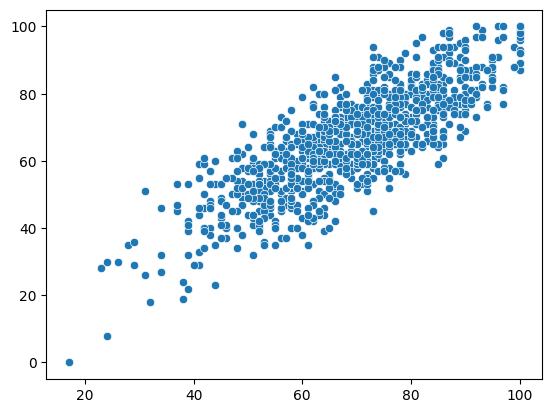

In [7]:
sns.scatterplot(x = read, y = math)

In [8]:
def make_prediction(x, w, b):
    return ((x * w) + b)

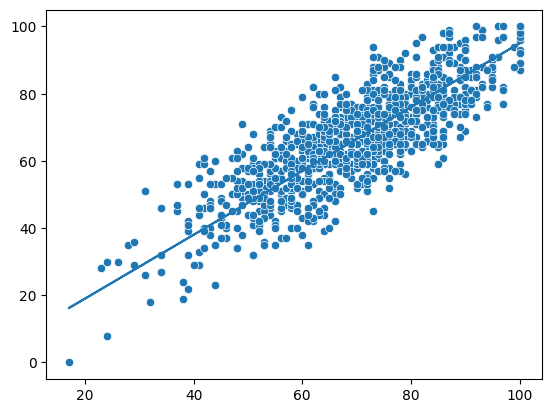

In [14]:
pred = make_prediction(read, 0.95, 0)
sns.scatterplot(x = read, y = math)
plt.plot(read, pred)

In [15]:
def compute_cost(pred, math):
    return np.mean((pred - math) ** 2)

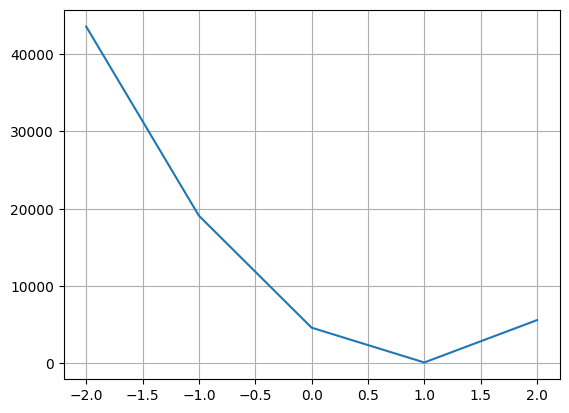

In [17]:
w = []
cost = []

for i in range(-2, 3):
    cost.append(compute_cost(make_prediction(read, i, b = 0), math))
    w.append(i)

plt.plot(w, cost)
plt.grid()

In [18]:
def calculate_gradient(read, math, w, b):
    n = len(read)

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(n):
        pred = make_prediction(read[i], w, b)
        error = pred - math[i]

        dj_dw += (error * read[i])
        dj_db += (error)

    dj_dw = (2 * dj_dw) / n
    dj_db = (2 * dj_db) / n

    return dj_db, dj_db

In [19]:
def gradient_descent(read, math, w_in, b_in, max_iter, alpha = 0.01):
    w = w_in
    b = b_in

    cost_his = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(read, math, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0:
            current_cost = compute_cost(make_prediction(read, w, b), math)
            cost_his.append(current_cost)

            print(f"Iter: {i:3d}: when w = {w:.4f}, b = {b:.4f}, cost = {current_cost:.4f}")
    return w, b, cost_his
    

w, b, cost_his = gradient_descent(read, math, 0, 0, 1000, alpha = 0.01)

Iter:   0: when w = 1.3218, b = 1.3218, cost = 834.4369
Iter: 100: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 200: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 300: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 400: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 500: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 600: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 700: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 800: when w = 0.9419, b = 0.9419, cost = 77.9886
Iter: 900: when w = 0.9419, b = 0.9419, cost = 77.9886


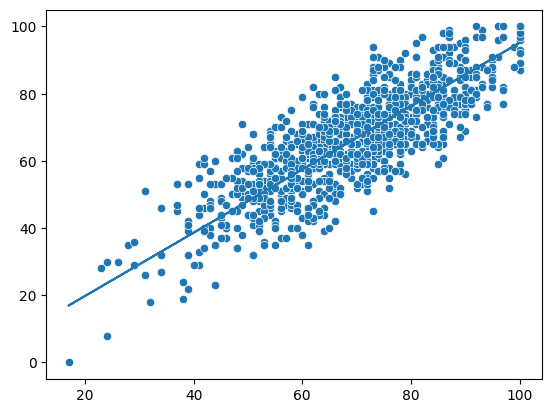

In [20]:
sns.scatterplot(x = read, y = math)
plt.plot(read, make_prediction(read, 0.9419, 0.9419))